# RAG-Stress — Qwen3.5-9B Statistical Analysis and Failure Modes

This notebook performs the full post-evaluation analysis for:

```text
Qwen/Qwen3.5-9B
```

It reads evaluated outputs from Google Drive:

```text
/content/drive/MyDrive/rag_stress/qwen35_9b/evaluation/
```

Expected input files:

```text
clean_evaluated.jsonl
distractor_evaluated.jsonl
position_evaluated.jsonl
counterfactual_v2_evaluated.jsonl
```

It saves all analysis outputs to:

```text
/content/drive/MyDrive/rag_stress/qwen35_9b/analysis/
```

The notebook includes:

- paired bootstrap confidence intervals
- McNemar tests for Exact Match
- Wilcoxon signed-rank tests for per-example F1
- Clean to D1/D3/D5 transition analysis
- distractor robustness trajectories
- clean-correct to perturbed-wrong rates
- position trajectories
- strict lost-in-the-middle analysis
- Counterfactual V2 CFR / GFR / OTHER
- Counterfactual V2 by semantic type
- Counterfactual V2 by replacement source
- representative qualitative failure examples
- publication-ready CSV tables
- publication-ready figures
- final machine-readable JSON summary


## 1. Install dependencies

In [1]:
!pip -q install -U pandas scipy matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 1.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 33.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 96.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.3, but you have pandas 3.0.6 which is incompatible.


## 2. Imports and Google Drive

In [3]:
from pathlib import Path
import json
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import wilcoxon, binomtest
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


## 3. Paths and configuration

In [4]:
MODEL_NAME = "Qwen/Qwen3.5-9B"
MODEL_TAG = "qwen35_9b"

DRIVE_ROOT = Path("/content/drive/MyDrive/rag_stress")

MODEL_ROOT = DRIVE_ROOT / MODEL_TAG
EVAL_DIR = MODEL_ROOT / "evaluation"
ANALYSIS_DIR = MODEL_ROOT / "analysis"
FIGURES_DIR = ANALYSIS_DIR / "figures"
EXAMPLES_DIR = ANALYSIS_DIR / "examples"

ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
EXAMPLES_DIR.mkdir(parents=True, exist_ok=True)

CLEAN_FILE = EVAL_DIR / "clean_evaluated.jsonl"
DISTRACTOR_FILE = EVAL_DIR / "distractor_evaluated.jsonl"
POSITION_FILE = EVAL_DIR / "position_evaluated.jsonl"
COUNTERFACTUAL_FILE = EVAL_DIR / "counterfactual_v2_evaluated.jsonl"

SEED = 42
N_BOOTSTRAP = 10000

print("Model:", MODEL_NAME)
print("Evaluation directory:", EVAL_DIR)
print("Analysis directory:", ANALYSIS_DIR)

Model: Qwen/Qwen3.5-9B
Evaluation directory: /content/drive/MyDrive/rag_stress/qwen35_9b/evaluation
Analysis directory: /content/drive/MyDrive/rag_stress/qwen35_9b/analysis


## 4. Load evaluated results

In [8]:
def load_jsonl(path):
    with Path(path).open("r", encoding="utf-8") as f:
        return [
            json.loads(line)
            for line in f
            if line.strip()
        ]


input_files = {
    "clean": CLEAN_FILE,
    "distractor": DISTRACTOR_FILE,
    "position": POSITION_FILE,
    "counterfactual_v2": COUNTERFACTUAL_FILE,
}

for name, path in input_files.items():
    print(
        f"{name:20s}",
        "FOUND" if path.exists() else "MISSING",
        "->",
        path,
    )

missing = [
    str(path)
    for path in input_files.values()
    if not path.exists()
]

assert not missing, (
    "Missing evaluated file(s)"+ "".join(missing)
    )

clean = load_jsonl(CLEAN_FILE)
distractor = load_jsonl(DISTRACTOR_FILE)
position = load_jsonl(POSITION_FILE)
counterfactual = load_jsonl(COUNTERFACTUAL_FILE)


print("Clean:", len(clean))
print("Distractor:", len(distractor))
print("Position:", len(position))
print("Counterfactual V2:", len(counterfactual))

clean                FOUND -> /content/drive/MyDrive/rag_stress/qwen35_9b/evaluation/clean_evaluated.jsonl
distractor           FOUND -> /content/drive/MyDrive/rag_stress/qwen35_9b/evaluation/distractor_evaluated.jsonl
position             FOUND -> /content/drive/MyDrive/rag_stress/qwen35_9b/evaluation/position_evaluated.jsonl
counterfactual_v2    FOUND -> /content/drive/MyDrive/rag_stress/qwen35_9b/evaluation/counterfactual_v2_evaluated.jsonl
Clean: 500
Distractor: 1500
Position: 1500
Counterfactual V2: 232


## 5. Verify required evaluation fields

In [9]:
required_standard = {
    "id",
    "question",
    "gold_answer",
    "model_answer",
    "em",
    "f1",
}

required_counterfactual = {
    "id",
    "question",
    "gold_answer",
    "counterfactual_answer",
    "model_answer",
    "cf_class",
}

for name, records in [
    ("clean", clean),
    ("distractor", distractor),
    ("position", position),
]:
    bad = [
        r.get("id")
        for r in records
        if not required_standard.issubset(r.keys())
    ]

    assert not bad, (
        f"{name} has rows missing required fields. "
        f"Example IDs: {bad[:10]}"
    )

bad_cf = [
    r.get("id")
    for r in counterfactual
    if not required_counterfactual.issubset(r.keys())
]

assert not bad_cf, (
    "Counterfactual V2 has rows missing required fields. "
    f"Example IDs: {bad_cf[:10]}"
)

print("Field validation passed.")

Field validation passed.


## 6. Convert to DataFrames

In [10]:
clean_df = pd.DataFrame(clean)
distractor_df = pd.DataFrame(distractor)
position_df = pd.DataFrame(position)
cf_df = pd.DataFrame(counterfactual)

print("Clean shape:", clean_df.shape)
print("Distractor shape:", distractor_df.shape)
print("Position shape:", position_df.shape)
print("Counterfactual V2 shape:", cf_df.shape)


Clean shape: (500, 15)
Distractor shape: (1500, 17)
Position shape: (1500, 17)
Counterfactual V2 shape: (232, 18)


## 7. Build paired clean/distractor matrix

In [11]:
clean_small = clean_df[
    [
        "id",
        "question",
        "gold_answer",
        "model_answer",
        "em",
        "f1",
    ]
].copy()

clean_small = clean_small.rename(
    columns={
        "model_answer": "clean_answer",
        "em": "clean_em",
        "f1": "clean_f1",
    }
)

dist_wide = distractor_df.pivot(
    index="id",
    columns="condition",
    values=["model_answer", "em", "f1"],
)

dist_wide.columns = [
    f"{metric}_{condition}"
    for metric, condition in dist_wide.columns
]

dist_wide = dist_wide.reset_index()

paired_dist = clean_small.merge(
    dist_wide,
    on="id",
    how="inner",
)

print(
    "Paired clean/distractor questions:",
    len(paired_dist),
)


Paired clean/distractor questions: 500


## 8. Build paired position matrix

In [12]:
pos_wide = position_df.pivot(
    index="id",
    columns="condition",
    values=["model_answer", "em", "f1"],
)

pos_wide.columns = [
    f"{metric}_{condition}"
    for metric, condition in pos_wide.columns
]

pos_wide = pos_wide.reset_index()

print(
    "Paired position questions:",
    len(pos_wide),
)


Paired position questions: 500


## 9. Paired bootstrap confidence intervals

In [13]:
def paired_bootstrap_difference(
    a,
    b,
    n_bootstrap=N_BOOTSTRAP,
    seed=SEED,
):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    assert len(a) == len(b)

    n = len(a)
    rng = np.random.default_rng(seed)

    observed = float(
        np.mean(a - b)
    )

    samples = np.empty(
        n_bootstrap,
        dtype=float,
    )

    for i in range(n_bootstrap):
        idx = rng.integers(
            0,
            n,
            size=n,
        )

        samples[i] = np.mean(
            a[idx] - b[idx]
        )

    low, high = np.percentile(
        samples,
        [2.5, 97.5],
    )

    return {
        "difference": observed,
        "ci_low": float(low),
        "ci_high": float(high),
    }


## 10. Exact McNemar test

In [14]:
def mcnemar_exact(a, b):
    a = np.asarray(
        a,
        dtype=int,
    )

    b = np.asarray(
        b,
        dtype=int,
    )

    a_correct_b_wrong = int(
        np.sum(
            (a == 1)
            & (b == 0)
        )
    )

    a_wrong_b_correct = int(
        np.sum(
            (a == 0)
            & (b == 1)
        )
    )

    discordant = (
        a_correct_b_wrong
        + a_wrong_b_correct
    )

    if discordant == 0:
        p_value = 1.0
    else:
        p_value = binomtest(
            min(
                a_correct_b_wrong,
                a_wrong_b_correct,
            ),
            n=discordant,
            p=0.5,
            alternative="two-sided",
        ).pvalue

    return {
        "a_correct_b_wrong":
            a_correct_b_wrong,

        "a_wrong_b_correct":
            a_wrong_b_correct,

        "discordant":
            discordant,

        "p_value":
            float(p_value),
    }


## 11. Wilcoxon signed-rank test for F1

In [15]:
def wilcoxon_f1(a, b):
    a = np.asarray(
        a,
        dtype=float,
    )

    b = np.asarray(
        b,
        dtype=float,
    )

    difference = (
        a - b
    )

    if np.allclose(
        difference,
        0,
    ):
        return {
            "statistic": 0.0,
            "p_value": 1.0,
        }

    result = wilcoxon(
        a,
        b,
        zero_method="wilcox",
        alternative="two-sided",
    )

    return {
        "statistic":
            float(result.statistic),

        "p_value":
            float(result.pvalue),
    }


## 12. Clean vs D1/D3/D5 statistical tests

In [16]:
distractor_stats = []

for condition in [
    "D1",
    "D3",
    "D5",
]:
    em_bootstrap = paired_bootstrap_difference(
        paired_dist["clean_em"],
        paired_dist[f"em_{condition}"],
    )

    f1_bootstrap = paired_bootstrap_difference(
        paired_dist["clean_f1"],
        paired_dist[f"f1_{condition}"],
    )

    mcnemar = mcnemar_exact(
        paired_dist["clean_em"],
        paired_dist[f"em_{condition}"],
    )

    wilcoxon_result = wilcoxon_f1(
        paired_dist["clean_f1"],
        paired_dist[f"f1_{condition}"],
    )

    distractor_stats.append(
        {
            "comparison":
                f"clean_vs_{condition}",

            "n":
                len(paired_dist),

            "clean_em":
                paired_dist["clean_em"].mean(),

            "condition_em":
                paired_dist[
                    f"em_{condition}"
                ].mean(),

            "em_difference_clean_minus_condition":
                em_bootstrap["difference"],

            "em_ci_low":
                em_bootstrap["ci_low"],

            "em_ci_high":
                em_bootstrap["ci_high"],

            "mcnemar_clean_correct_condition_wrong":
                mcnemar[
                    "a_correct_b_wrong"
                ],

            "mcnemar_clean_wrong_condition_correct":
                mcnemar[
                    "a_wrong_b_correct"
                ],

            "mcnemar_p":
                mcnemar["p_value"],

            "clean_f1":
                paired_dist["clean_f1"].mean(),

            "condition_f1":
                paired_dist[
                    f"f1_{condition}"
                ].mean(),

            "f1_difference_clean_minus_condition":
                f1_bootstrap["difference"],

            "f1_ci_low":
                f1_bootstrap["ci_low"],

            "f1_ci_high":
                f1_bootstrap["ci_high"],

            "wilcoxon_f1_p":
                wilcoxon_result["p_value"],
        }
    )


distractor_stats_df = pd.DataFrame(
    distractor_stats
)

display(
    distractor_stats_df.round(6)
)


,comparison,n,clean_em,condition_em,em_difference_clean_minus_condition,em_ci_low,em_ci_high,mcnemar_clean_correct_condition_wrong,mcnemar_clean_wrong_condition_correct,mcnemar_p,clean_f1,condition_f1,f1_difference_clean_minus_condition,f1_ci_low,f1_ci_high,wilcoxon_f1_p
0,clean_vs_D1,500,0.62,0.606,0.014,-0.004,0.032,14,7,0.189247,0.775099,0.765696,0.009403,-0.006402,0.025824,0.230270
1,clean_vs_D3,500,0.62,0.602,0.018,-0.006,0.042,23,14,0.187742,0.775099,0.751793,0.023306,0.001184,0.045354,0.041079
2,clean_vs_D5,500,0.62,0.606,0.014,-0.010,0.038,23,16,0.336784,0.775099,0.757472,0.017627,-0.004925,0.040082,0.117546


## 13. Position statistical tests

In [17]:
position_pairs = [
    ("beginning", "middle"),
    ("middle", "end"),
    ("beginning", "end"),
]

position_stats = []

for a, b in position_pairs:
    em_bootstrap = paired_bootstrap_difference(
        pos_wide[f"em_{a}"],
        pos_wide[f"em_{b}"],
    )

    f1_bootstrap = paired_bootstrap_difference(
        pos_wide[f"f1_{a}"],
        pos_wide[f"f1_{b}"],
    )

    mcnemar = mcnemar_exact(
        pos_wide[f"em_{a}"],
        pos_wide[f"em_{b}"],
    )

    wilcoxon_result = wilcoxon_f1(
        pos_wide[f"f1_{a}"],
        pos_wide[f"f1_{b}"],
    )

    position_stats.append(
        {
            "comparison":
                f"{a}_vs_{b}",

            "n":
                len(pos_wide),

            "a_em":
                pos_wide[
                    f"em_{a}"
                ].mean(),

            "b_em":
                pos_wide[
                    f"em_{b}"
                ].mean(),

            "em_difference_a_minus_b":
                em_bootstrap["difference"],

            "em_ci_low":
                em_bootstrap["ci_low"],

            "em_ci_high":
                em_bootstrap["ci_high"],

            "mcnemar_p":
                mcnemar["p_value"],

            "a_f1":
                pos_wide[
                    f"f1_{a}"
                ].mean(),

            "b_f1":
                pos_wide[
                    f"f1_{b}"
                ].mean(),

            "f1_difference_a_minus_b":
                f1_bootstrap["difference"],

            "f1_ci_low":
                f1_bootstrap["ci_low"],

            "f1_ci_high":
                f1_bootstrap["ci_high"],

            "wilcoxon_f1_p":
                wilcoxon_result["p_value"],
        }
    )


position_stats_df = pd.DataFrame(
    position_stats
)

display(
    position_stats_df.round(6)
)


,comparison,n,a_em,b_em,em_difference_a_minus_b,em_ci_low,em_ci_high,mcnemar_p,a_f1,b_f1,f1_difference_a_minus_b,f1_ci_low,f1_ci_high,wilcoxon_f1_p
0,beginning_vs_middle,500,0.600,0.582,0.018,-0.002,0.038,0.107752,0.746928,0.728375,0.018554,-0.000014,0.037474,0.055488
1,middle_vs_end,500,0.582,0.598,-0.016,-0.036,0.004,0.168638,0.728375,0.752094,-0.023720,-0.042333,-0.006379,0.012006
2,beginning_vs_end,500,0.600,0.598,0.002,-0.020,0.024,1.000000,0.746928,0.752094,-0.005166,-0.025033,0.014456,0.641575


## 14. Distractor robustness trajectories

In [18]:
paired_dist["trajectory"] = (
    paired_dist.apply(
        lambda row:
            f'{int(row["clean_em"])}'
            f'->{int(row["em_D1"])}'
            f'->{int(row["em_D3"])}'
            f'->{int(row["em_D5"])}',
        axis=1,
    )
)

trajectory_counts = (
    paired_dist[
        "trajectory"
    ]
    .value_counts()
    .rename_axis(
        "trajectory"
    )
    .reset_index(
        name="count"
    )
)

trajectory_counts["rate"] = (
    trajectory_counts["count"]
    / len(paired_dist)
)

display(
    trajectory_counts
)


,trajectory,count,rate
0,1->1->1->1,278,0.556
1,0->0->0->0,171,0.342
2,1->0->0->0,9,0.018
3,0->0->1->1,7,0.014
4,1->1->0->0,7,0.014
5,1->1->0->1,6,0.012
6,1->1->1->0,5,0.010
7,0->1->1->1,4,0.008
8,0->0->0->1,3,0.006
9,1->0->1->1,2,0.004


## 15. Distractor trajectory classes

In [19]:
def categorize_trajectory(row):
    values = [
        int(row["clean_em"]),
        int(row["em_D1"]),
        int(row["em_D3"]),
        int(row["em_D5"]),
    ]

    if values == [1, 1, 1, 1]:
        return "ROBUST_ALL"

    if values == [1, 0, 0, 0]:
        return "FAILS_AT_D1"

    if values == [1, 1, 0, 0]:
        return "FAILS_AT_D3"

    if values == [1, 1, 1, 0]:
        return "FAILS_AT_D5"

    if (
        values[0] == 1
        and any(
            value == 0
            for value in values[1:]
        )
    ):
        return "NON_MONOTONIC_DEGRADATION"

    if (
        values[0] == 0
        and any(
            value == 1
            for value in values[1:]
        )
    ):
        return "PERTURBATION_RECOVERY"

    if values == [0, 0, 0, 0]:
        return "ALWAYS_WRONG"

    return "OTHER"


paired_dist[
    "trajectory_class"
] = paired_dist.apply(
    categorize_trajectory,
    axis=1,
)

trajectory_class_summary = (
    paired_dist[
        "trajectory_class"
    ]
    .value_counts()
    .rename_axis(
        "class"
    )
    .reset_index(
        name="count"
    )
)

trajectory_class_summary[
    "rate"
] = (
    trajectory_class_summary["count"]
    / len(paired_dist)
)

display(
    trajectory_class_summary
)


,class,count,rate
0,ROBUST_ALL,278,0.556
1,ALWAYS_WRONG,171,0.342
2,PERTURBATION_RECOVERY,19,0.038
3,NON_MONOTONIC_DEGRADATION,11,0.022
4,FAILS_AT_D1,9,0.018
5,FAILS_AT_D3,7,0.014
6,FAILS_AT_D5,5,0.010


## 16. Clean-correct to perturbed-wrong rates

In [20]:
clean_correct = paired_dist[
    paired_dist["clean_em"] == 1
].copy()

transition_rows = []

for condition in [
    "D1",
    "D3",
    "D5",
]:
    failures = int(
        (
            clean_correct[
                f"em_{condition}"
            ]
            == 0
        ).sum()
    )

    transition_rows.append(
        {
            "condition":
                condition,

            "clean_correct_n":
                len(clean_correct),

            "clean_correct_to_wrong":
                failures,

            "failure_rate_given_clean_correct":
                failures
                / len(clean_correct)
                if len(clean_correct)
                else np.nan,
        }
    )


transition_df = pd.DataFrame(
    transition_rows
)

display(
    transition_df.round(4)
)


,condition,clean_correct_n,clean_correct_to_wrong,failure_rate_given_clean_correct
0,D1,310,14,0.0452
1,D3,310,23,0.0742
2,D5,310,23,0.0742


## 17. Position trajectories

In [21]:
pos_wide["trajectory"] = (
    pos_wide.apply(
        lambda row:
            f'{int(row["em_beginning"])}'
            f'->{int(row["em_middle"])}'
            f'->{int(row["em_end"])}',
        axis=1,
    )
)

position_trajectory_counts = (
    pos_wide[
        "trajectory"
    ]
    .value_counts()
    .rename_axis(
        "trajectory"
    )
    .reset_index(
        name="count"
    )
)

position_trajectory_counts[
    "rate"
] = (
    position_trajectory_counts["count"]
    / len(pos_wide)
)

display(
    position_trajectory_counts
)


,trajectory,count,rate
0,1->1->1,275,0.550
1,0->0->0,185,0.370
2,1->0->1,10,0.020
3,1->1->0,8,0.016
4,0->1->1,7,0.014
5,1->0->0,7,0.014
6,0->0->1,7,0.014
7,0->1->0,1,0.002


## 18. Strict lost-in-the-middle analysis

In [22]:
lost_middle = pos_wide[
    (pos_wide["em_beginning"] == 1)
    & (pos_wide["em_middle"] == 0)
    & (pos_wide["em_end"] == 1)
].copy()

lost_middle_rate = (
    len(lost_middle)
    / len(pos_wide)
)

edge_correct = pos_wide[
    (pos_wide["em_beginning"] == 1)
    | (pos_wide["em_end"] == 1)
].copy()

middle_failure_given_edge_success = (
    (
        edge_correct[
            "em_middle"
        ]
        == 0
    ).mean()
    if len(edge_correct)
    else np.nan
)

print(
    "Strict lost-in-the-middle count:",
    len(lost_middle),
)

print(
    "Strict lost-in-the-middle rate:",
    round(
        float(lost_middle_rate),
        4,
    ),
)

print(
    "Questions correct at beginning or end:",
    len(edge_correct),
)

print(
    "Middle-failure rate among edge-success questions:",
    round(
        float(
            middle_failure_given_edge_success
        ),
        4,
    ),
)


Strict lost-in-the-middle count: 10
Strict lost-in-the-middle rate: 0.02
Questions correct at beginning or end: 314
Middle-failure rate among edge-success questions: 0.0764


## 19. Counterfactual V2 overall behavior

In [23]:
cf_counts = (
    cf_df[
        "cf_class"
    ]
    .value_counts()
)

cf_summary = pd.DataFrame(
    {
        "behavior": [
            "COUNTERFACTUAL_FOLLOW",
            "GOLD_FOLLOW",
            "OTHER",
        ],

        "count": [
            int(
                cf_counts.get(
                    "COUNTERFACTUAL_FOLLOW",
                    0,
                )
            ),
            int(
                cf_counts.get(
                    "GOLD_FOLLOW",
                    0,
                )
            ),
            int(
                cf_counts.get(
                    "OTHER",
                    0,
                )
            ),
        ],
    }
)

cf_summary["rate"] = (
    cf_summary["count"]
    / len(cf_df)
)

display(
    cf_summary.round(4)
)


,behavior,count,rate
0,COUNTERFACTUAL_FOLLOW,138,0.5948
1,GOLD_FOLLOW,7,0.0302
2,OTHER,87,0.3750


## 20. Counterfactual V2 by semantic type

In [24]:
cf_by_type = (
    cf_df
    .groupby(
        [
            "counterfactual_type",
            "cf_class",
        ]
    )
    .size()
    .unstack(
        fill_value=0
    )
)

for column in [
    "COUNTERFACTUAL_FOLLOW",
    "GOLD_FOLLOW",
    "OTHER",
]:
    if column not in cf_by_type.columns:
        cf_by_type[column] = 0

cf_by_type["total"] = (
    cf_by_type[
        [
            "COUNTERFACTUAL_FOLLOW",
            "GOLD_FOLLOW",
            "OTHER",
        ]
    ].sum(axis=1)
)

cf_by_type["CFR"] = (
    cf_by_type[
        "COUNTERFACTUAL_FOLLOW"
    ]
    / cf_by_type["total"]
)

cf_by_type["GFR"] = (
    cf_by_type[
        "GOLD_FOLLOW"
    ]
    / cf_by_type["total"]
)

cf_by_type["OTHER_rate"] = (
    cf_by_type[
        "OTHER"
    ]
    / cf_by_type["total"]
)

cf_by_type = (
    cf_by_type
    .sort_values(
        "total",
        ascending=False,
    )
)

display(
    cf_by_type.round(4)
)


cf_class,COUNTERFACTUAL_FOLLOW,GOLD_FOLLOW,OTHER,total,CFR,GFR,OTHER_rate
counterfactual_type,,,,,,,
NUMERIC,51,1,33,85,0.6000,0.0118,0.3882
EXPLICIT_ALTERNATIVE,5,3,11,19,0.2632,0.1579,0.5789
CITY,13,0,2,15,0.8667,0.0000,0.1333
LOCATION,11,0,3,14,0.7857,0.0000,0.2143
PERSON_MUSICIAN,5,1,6,12,0.4167,0.0833,0.5000
NATIONALITY,6,0,1,7,0.8571,0.0000,0.1429
PERSON_ACTOR,2,0,5,7,0.2857,0.0000,0.7143
PERSON_DIRECTOR,2,0,4,6,0.3333,0.0000,0.6667
FILM,2,0,3,5,0.4000,0.0000,0.6000


## 21. Counterfactual V2 by replacement source

In [25]:
cf_by_source = (
    cf_df
    .groupby(
        [
            "replacement_source",
            "cf_class",
        ]
    )
    .size()
    .unstack(
        fill_value=0
    )
)

for column in [
    "COUNTERFACTUAL_FOLLOW",
    "GOLD_FOLLOW",
    "OTHER",
]:
    if column not in cf_by_source.columns:
        cf_by_source[column] = 0

cf_by_source["total"] = (
    cf_by_source[
        [
            "COUNTERFACTUAL_FOLLOW",
            "GOLD_FOLLOW",
            "OTHER",
        ]
    ].sum(axis=1)
)

cf_by_source["CFR"] = (
    cf_by_source[
        "COUNTERFACTUAL_FOLLOW"
    ]
    / cf_by_source["total"]
)

cf_by_source["GFR"] = (
    cf_by_source[
        "GOLD_FOLLOW"
    ]
    / cf_by_source["total"]
)

cf_by_source["OTHER_rate"] = (
    cf_by_source[
        "OTHER"
    ]
    / cf_by_source["total"]
)

display(
    cf_by_source.round(4)
)


cf_class,COUNTERFACTUAL_FOLLOW,GOLD_FOLLOW,OTHER,total,CFR,GFR,OTHER_rate
replacement_source,,,,,,,
numeric_transform_question_aware,51,1,33,85,0.6000,0.0118,0.3882
question_explicit_alternative,7,6,13,26,0.2692,0.2308,0.5000
strict_type_bank,80,0,41,121,0.6612,0.0000,0.3388


## 22. Representative failure examples

In [26]:
d5_induced_failures = paired_dist[
    (paired_dist["clean_em"] == 1)
    & (paired_dist["em_D5"] == 0)
].copy()

lost_middle_examples = lost_middle.merge(
    clean_df[
        [
            "id",
            "question",
            "gold_answer",
        ]
    ],
    on="id",
    how="left",
)

cf_follow_examples = cf_df[
    cf_df["cf_class"]
    == "COUNTERFACTUAL_FOLLOW"
].copy()

gold_follow_examples = cf_df[
    cf_df["cf_class"]
    == "GOLD_FOLLOW"
].copy()

cf_other_examples = cf_df[
    cf_df["cf_class"]
    == "OTHER"
].copy()

print(
    "D5-induced failures:",
    len(d5_induced_failures),
)

print(
    "Strict lost-in-the-middle examples:",
    len(lost_middle_examples),
)

print(
    "Counterfactual-follow examples:",
    len(cf_follow_examples),
)

print(
    "Gold-follow examples:",
    len(gold_follow_examples),
)

print(
    "Counterfactual OTHER examples:",
    len(cf_other_examples),
)


D5-induced failures: 23
Strict lost-in-the-middle examples: 10
Counterfactual-follow examples: 138
Gold-follow examples: 7
Counterfactual OTHER examples: 87


## 23. Save statistical tables

In [27]:
distractor_stats_df.to_csv(
    ANALYSIS_DIR
    / "distractor_significance_tests.csv",
    index=False,
)

position_stats_df.to_csv(
    ANALYSIS_DIR
    / "position_significance_tests.csv",
    index=False,
)

trajectory_counts.to_csv(
    ANALYSIS_DIR
    / "distractor_trajectory_counts.csv",
    index=False,
)

trajectory_class_summary.to_csv(
    ANALYSIS_DIR
    / "distractor_trajectory_classes.csv",
    index=False,
)

transition_df.to_csv(
    ANALYSIS_DIR
    / "clean_correct_to_perturbed_wrong.csv",
    index=False,
)

position_trajectory_counts.to_csv(
    ANALYSIS_DIR
    / "position_trajectory_counts.csv",
    index=False,
)

cf_summary.to_csv(
    ANALYSIS_DIR
    / "counterfactual_v2_behavior_summary.csv",
    index=False,
)

cf_by_type.to_csv(
    ANALYSIS_DIR
    / "counterfactual_v2_by_type.csv"
)

cf_by_source.to_csv(
    ANALYSIS_DIR
    / "counterfactual_v2_by_replacement_source.csv"
)

print(
    "Saved statistical analysis tables to:",
    ANALYSIS_DIR,
)


Saved statistical analysis tables to: /content/drive/MyDrive/rag_stress/qwen35_9b/analysis


## 24. Save representative examples

In [28]:
d5_induced_failures.to_csv(
    EXAMPLES_DIR
    / "d5_induced_failures.csv",
    index=False,
)

lost_middle_examples.to_csv(
    EXAMPLES_DIR
    / "lost_in_middle_examples.csv",
    index=False,
)

cf_follow_examples.to_csv(
    EXAMPLES_DIR
    / "counterfactual_v2_follow_examples.csv",
    index=False,
)

gold_follow_examples.to_csv(
    EXAMPLES_DIR
    / "counterfactual_v2_gold_follow_examples.csv",
    index=False,
)

cf_other_examples.to_csv(
    EXAMPLES_DIR
    / "counterfactual_v2_other_examples.csv",
    index=False,
)

print(
    "Saved qualitative examples to:",
    EXAMPLES_DIR,
)


Saved qualitative examples to: /content/drive/MyDrive/rag_stress/qwen35_9b/analysis/examples


## 25. Figure: Distractor robustness

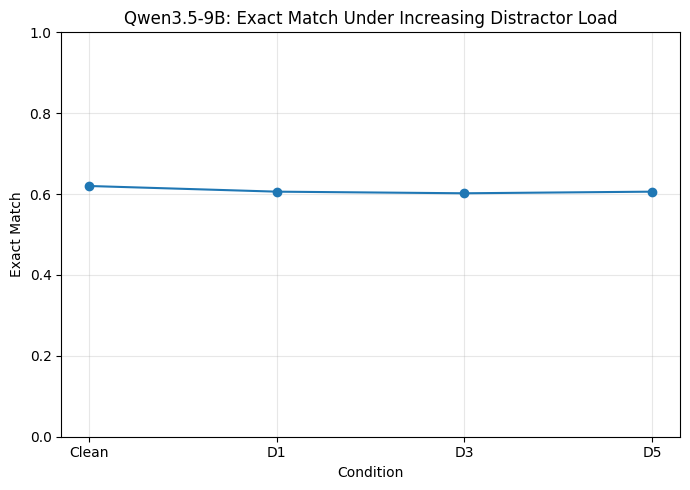

In [29]:
conditions = [
    "Clean",
    "D1",
    "D3",
    "D5",
]

values = [
    paired_dist[
        "clean_em"
    ].mean(),

    paired_dist[
        "em_D1"
    ].mean(),

    paired_dist[
        "em_D3"
    ].mean(),

    paired_dist[
        "em_D5"
    ].mean(),
]

plt.figure(
    figsize=(7, 5)
)

plt.plot(
    conditions,
    values,
    marker="o",
)

plt.xlabel(
    "Condition"
)

plt.ylabel(
    "Exact Match"
)

plt.title(
    "Qwen3.5-9B: Exact Match Under Increasing Distractor Load"
)

plt.ylim(
    0,
    1
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "distractor_em.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


## 26. Figure: Position sensitivity

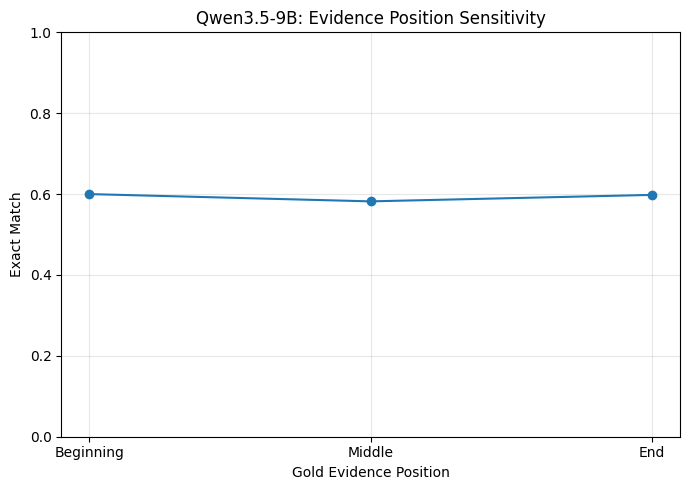

In [30]:
conditions = [
    "Beginning",
    "Middle",
    "End",
]

values = [
    pos_wide[
        "em_beginning"
    ].mean(),

    pos_wide[
        "em_middle"
    ].mean(),

    pos_wide[
        "em_end"
    ].mean(),
]

plt.figure(
    figsize=(7, 5)
)

plt.plot(
    conditions,
    values,
    marker="o",
)

plt.xlabel(
    "Gold Evidence Position"
)

plt.ylabel(
    "Exact Match"
)

plt.title(
    "Qwen3.5-9B: Evidence Position Sensitivity"
)

plt.ylim(
    0,
    1
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "position_em.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


## 27. Figure: Counterfactual V2 behavior

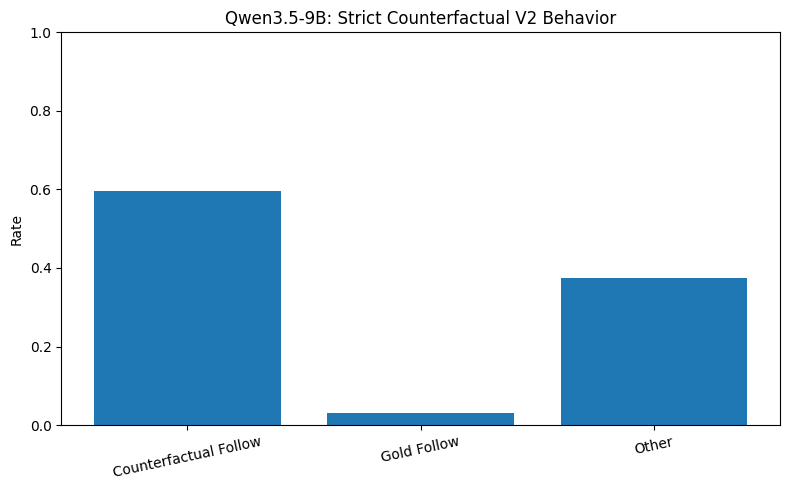

In [31]:
behavior_order = [
    "COUNTERFACTUAL_FOLLOW",
    "GOLD_FOLLOW",
    "OTHER",
]

behavior_rates = []

for behavior in behavior_order:
    row = cf_summary[
        cf_summary["behavior"]
        == behavior
    ]

    behavior_rates.append(
        float(
            row["rate"].iloc[0]
        )
    )

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    [
        "Counterfactual Follow",
        "Gold Follow",
        "Other",
    ],
    behavior_rates,
)

plt.ylabel(
    "Rate"
)

plt.title(
    "Qwen3.5-9B: Strict Counterfactual V2 Behavior"
)

plt.ylim(
    0,
    1
)

plt.xticks(
    rotation=12
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "counterfactual_v2_behavior.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


## 28. Figure: CFR by semantic type

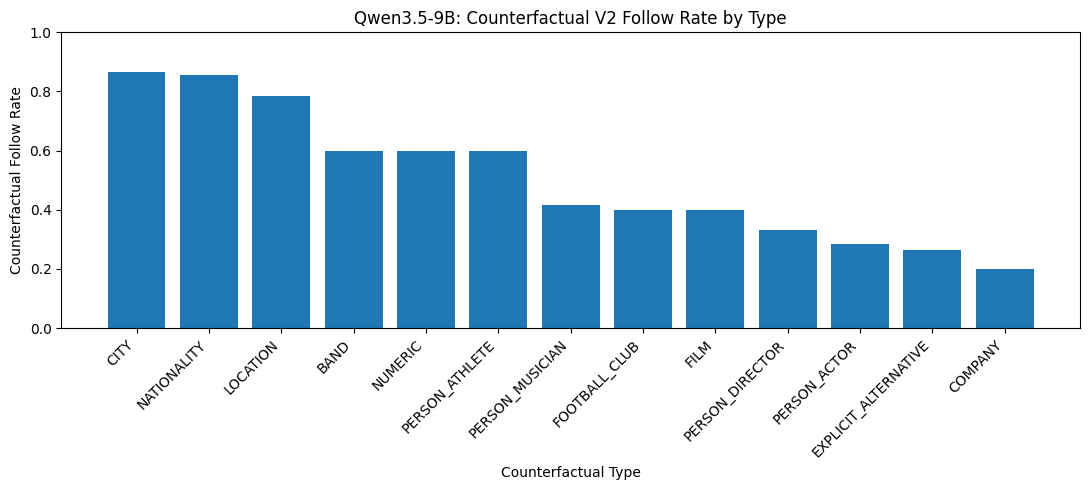

In [32]:
plot_df = (
    cf_by_type[
        cf_by_type["total"] >= 5
    ]
    .sort_values(
        "CFR",
        ascending=False,
    )
    .reset_index()
)

plt.figure(
    figsize=(11, 5)
)

plt.bar(
    plot_df[
        "counterfactual_type"
    ],
    plot_df[
        "CFR"
    ],
)

plt.xlabel(
    "Counterfactual Type"
)

plt.ylabel(
    "Counterfactual Follow Rate"
)

plt.title(
    "Qwen3.5-9B: Counterfactual V2 Follow Rate by Type"
)

plt.ylim(
    0,
    1
)

plt.xticks(
    rotation=45,
    ha="right",
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR
    / "counterfactual_v2_cfr_by_type.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()


## 29. Final analysis summary

In [34]:
cf_rate_map = {
    row["behavior"]: float(row["rate"])
    for _, row in cf_summary.iterrows()
}

analysis_summary = {
    "model": MODEL_NAME,

    "n_clean": int(len(clean_df)),
    "n_distractor_rows": int(len(distractor_df)),
    "n_position_rows": int(len(position_df)),
    "n_counterfactual_v2": int(len(cf_df)),

    "distractor": {
        "clean_em": float(
            paired_dist["clean_em"].mean()
        ),

        "D1_em": float(
            paired_dist["em_D1"].mean()
        ),

        "D3_em": float(
            paired_dist["em_D3"].mean()
        ),

        "D5_em": float(
            paired_dist["em_D5"].mean()
        ),

        "clean_correct_n": int(
            len(clean_correct)
        ),

        "clean_correct_to_D1_wrong_rate": float(
            transition_df.loc[
                transition_df["condition"] == "D1",
                "failure_rate_given_clean_correct",
            ].iloc[0]
        ),

        "clean_correct_to_D3_wrong_rate": float(
            transition_df.loc[
                transition_df["condition"] == "D3",
                "failure_rate_given_clean_correct",
            ].iloc[0]
        ),

        "clean_correct_to_D5_wrong_rate": float(
            transition_df.loc[
                transition_df["condition"] == "D5",
                "failure_rate_given_clean_correct",
            ].iloc[0]
        ),
    },

    "position": {
        "beginning_em": float(
            pos_wide["em_beginning"].mean()
        ),

        "middle_em": float(
            pos_wide["em_middle"].mean()
        ),

        "end_em": float(
            pos_wide["em_end"].mean()
        ),

        "strict_lost_middle_count": int(
            len(lost_middle)
        ),

        "strict_lost_middle_rate": float(
            lost_middle_rate
        ),

        "middle_fail_given_edge_success": float(
            middle_failure_given_edge_success
        ),
    },

    "counterfactual_v2": {
        "CFR": cf_rate_map.get(
            "COUNTERFACTUAL_FOLLOW",
            0.0,
        ),

        "GFR": cf_rate_map.get(
            "GOLD_FOLLOW",
            0.0,
        ),

        "OTHER_rate": cf_rate_map.get(
            "OTHER",
            0.0,
        ),
    },
}

SUMMARY_FILE = (
    ANALYSIS_DIR
    / "qwen35_9b_statistical_analysis_summary.json"
)

with SUMMARY_FILE.open(
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        analysis_summary,
        f,
        indent=2,
    )

print(
    json.dumps(
        analysis_summary,
        indent=2,
    )
)

print()
print("Saved:", SUMMARY_FILE)

{
  "model": "Qwen/Qwen3.5-9B",
  "n_clean": 500,
  "n_distractor_rows": 1500,
  "n_position_rows": 1500,
  "n_counterfactual_v2": 232,
  "distractor": {
    "clean_em": 0.62,
    "D1_em": 0.606,
    "D3_em": 0.602,
    "D5_em": 0.606,
    "clean_correct_n": 310,
    "clean_correct_to_D1_wrong_rate": 0.04516129032258064,
    "clean_correct_to_D3_wrong_rate": 0.07419354838709677,
    "clean_correct_to_D5_wrong_rate": 0.07419354838709677
  },
  "position": {
    "beginning_em": 0.6,
    "middle_em": 0.582,
    "end_em": 0.598,
    "strict_lost_middle_count": 10,
    "strict_lost_middle_rate": 0.02,
    "middle_fail_given_edge_success": 0.07643312101910828
  },
  "counterfactual_v2": {
    "CFR": 0.5948275862068966,
    "GFR": 0.03017241379310345,
    "OTHER_rate": 0.375
  }
}

Saved: /content/drive/MyDrive/rag_stress/qwen35_9b/analysis/qwen35_9b_statistical_analysis_summary.json


## 30. Final Google Drive manifest

In [36]:
print("Analysis directory:")
print(ANALYSIS_DIR)

print()
print("Analysis files:")

for path in sorted(
    ANALYSIS_DIR.glob("*")
):
    if path.is_file():
        print("-", path.name)

print()
print("Figures:")

for path in sorted(
    FIGURES_DIR.glob("*")
):
    print("-", path.name)

print()
print("Example files:")

for path in sorted(
    EXAMPLES_DIR.glob("*")
):
    print("-", path.name)

Analysis directory:
/content/drive/MyDrive/rag_stress/qwen35_9b/analysis

Analysis files:
- clean_correct_to_perturbed_wrong.csv
- counterfactual_v2_behavior_summary.csv
- counterfactual_v2_by_replacement_source.csv
- counterfactual_v2_by_type.csv
- distractor_significance_tests.csv
- distractor_trajectory_classes.csv
- distractor_trajectory_counts.csv
- position_significance_tests.csv
- position_trajectory_counts.csv
- qwen35_9b_statistical_analysis_summary.json

Figures:
- counterfactual_v2_behavior.png
- counterfactual_v2_cfr_by_type.png
- distractor_em.png
- position_em.png

Example files:
- counterfactual_v2_follow_examples.csv
- counterfactual_v2_gold_follow_examples.csv
- counterfactual_v2_other_examples.csv
- d5_induced_failures.csv
- lost_in_middle_examples.csv
